In [9]:
import cv2
import numpy as np


# 1. Read the image (make sure 'lena.jpg' is in the same directory)
img_color = cv2.imread('lena.jpg')

# Check if image loaded correctly
if img_color is None:
    print("Error: Could not read image file. Please check the path and filename.")
else:
    # 2. Convert to grayscale
    # img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)

    # 3. Apply Otsu's thresholding to get a binary image
    # 'ret' is the optimal threshold value found by the algorithm
    ret, img_binary = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    print(f"Otsu's calculated threshold value: {ret}")
    cv2.imwrite('lena_binary.jpg', img_binary)

# Define a simple 5x5 rectangular structuring element
kernel = np.ones((3,3),np.uint8)

# Apply Erosion and Dilation
eroded_image = cv2.erode(img_binary, kernel, iterations = 1)
dilated_image = cv2.dilate(img_binary, kernel, iterations = 1)

# Display results
# ...
cv2.imshow('Binary Image', img_binary)
cv2.imshow('Eroded Image', eroded_image)
cv2.imshow('Dilated Image', dilated_image)
cv2.waitKey(0)

Otsu's calculated threshold value: 117.0


-1

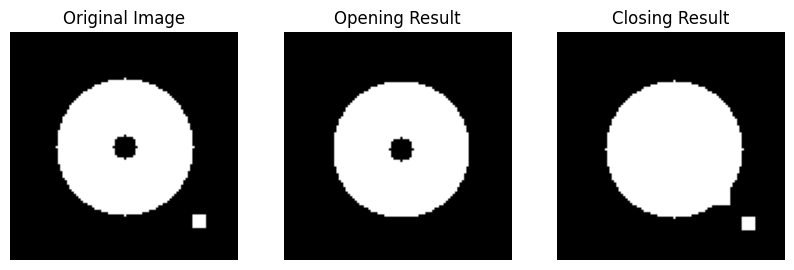

In [11]:
import cv2
import numpy as np

import matplotlib.pyplot as plt

# Load the image (make sure to use a binary or grayscale image for best results)
# For this example, let's assume 'image.png' is in the current directory.
# If you don't have an image, you can create a simple binary array with NumPy.
# img = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)
# _, binary_img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Create a sample image with noise (white dots) and holes (black dots)
img = np.zeros((100, 100), dtype=np.uint8)
cv2.circle(img, (50, 50), 30, 255, -1) # Main object
cv2.circle(img, (50, 50), 5, 0, -1)   # Small hole
cv2.rectangle(img, (80, 80), (85, 85), 255, -1) # Small noise object

# Define a structuring element (kernel)
kernel = np.ones((12, 12), np.uint8) # A 5x5 square kernel

# --- Opening Operation ---
# Erosion followed by dilation
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

# --- Closing Operation ---
# Dilation followed by erosion
closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1), plt.imshow(img, cmap='gray'), plt.title('Original Image')
plt.subplot(1, 3, 2), plt.imshow(opening, cmap='gray'), plt.title('Opening Result')
plt.subplot(1, 3, 3), plt.imshow(closing, cmap='gray'), plt.title('Closing Result')
for ax in plt.gcf().axes:
    ax.axis('off')
plt.show()
